✅ Задание №1.

Цель: Научиться анализировать временные ряды и понимать их структуру.
Описание задания:

Используя предоставленный вами код (анализ компонентов временного ряда), выполните следующее:

- Измените интенсивность сезонности в искусственном временном ряде (увеличивайте амплитуду колебаний сезонности вдвое).
- Проверьте, изменится ли характер распределения остатков ("шума"). Какие выводы можно сделать?
- Сохраните получившиеся графики компонент и исходного временного ряда в файл формата .png.

Решение:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Настройки отображения графиков
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Генерация синтетического временного ряда
rng = np.random.default_rng(seed=42)
index = pd.date_range(start="2020-01-01", end="2022-12-31", freq="MS")  # Ежемесячные интервалы
trend = np.linspace(-50, 50, len(index))   # Линейный тренд
seasonality = np.sin((index.month % 12)/6*np.pi) * 20  # Годовая синусоидальная сезонность
noise = rng.normal(scale=5, size=len(index))  # Шум

sales_data = trend + seasonality + noise
ts = pd.Series(sales_data, index=index)

# Декомпозиция временного ряда
decomposition = seasonal_decompose(ts, model='additive')
fig, axes = plt.subplots(4, 1, sharex=True)
axes[0].plot(decomposition.observed); axes[0].set_title('Наблюдаемые данные');
axes[1].plot(decomposition.trend); axes[1].set_title('Тренд');
axes[2].plot(decomposition.seasonal); axes[2].set_title('Сезонность');
axes[3].plot(decomposition.resid); axes[3].set_title('Шум');
plt.show()


Задание:

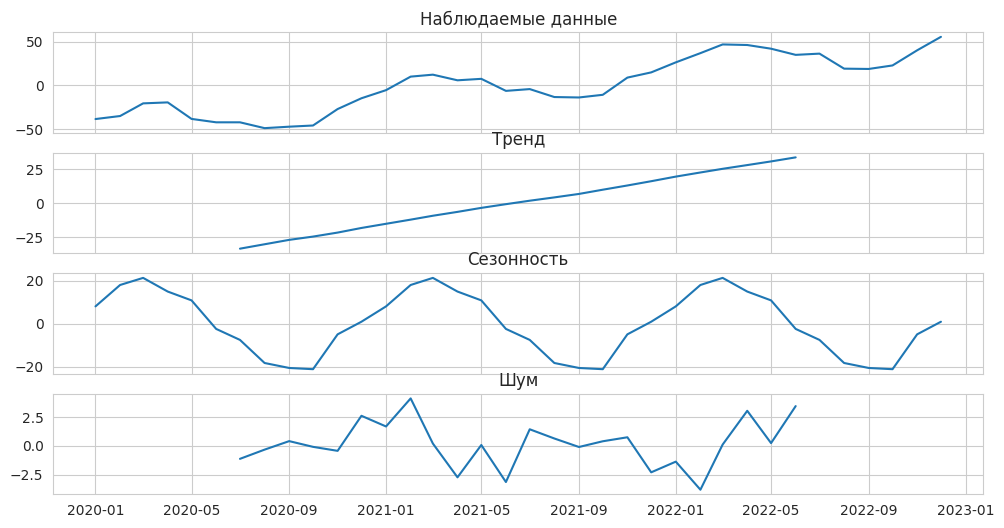

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Настройки отображения графиков
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Генерация синтетического временного ряда
rng = np.random.default_rng(seed=42)
index = pd.date_range(start="2020-01-01", end="2022-12-31", freq="MS")  # Ежемесячные интервалы
trend = np.linspace(-50, 50, len(index))   # Линейный тренд
seasonality = np.sin((index.month % 12)/6*np.pi) * 20  # Годовая синусоидальная сезонность
noise = rng.normal(scale=5, size=len(index))  # Шум

sales_data = trend + seasonality + noise
ts = pd.Series(sales_data, index=index)

# Декомпозиция временного ряда
decomposition = seasonal_decompose(ts, model='additive')
fig, axes = plt.subplots(4, 1, sharex=True)
axes[0].plot(decomposition.observed); axes[0].set_title('Наблюдаемые данные');
axes[1].plot(decomposition.trend); axes[1].set_title('Тренд');
axes[2].plot(decomposition.seasonal); axes[2].set_title('Сезонность');
axes[3].plot(decomposition.resid); axes[3].set_title('Шум');
plt.show()


---------------------------------------------------------------------

✅ Задание №2.

Цель: Освоить настройку параметров модели ARIMA и оценку качества прогноза.
Описание задания:

На основе предоставленного кода (моделирование ARIMA):

- Попробуйте изменить порядок интегрированности (d) модели ARIMA на 2 и посмотрите, улучшится ли качество прогноза.
- Запустите цикл перебора нескольких комбинаций параметров p, d, q (например, (0,1,1) и (2,1,2)). Определите лучшую комбинацию по значению MAE/RMSE.
- Добавьте дополнительную метрику MSE для сравнения результатов разных конфигураций.



Задание:

In [ ]:
# Определение и оценка ARIMA-модели
model = ARIMA(ts, order=(1,1,1))
fit_result = model.fit()
forecast = fit_result.forecast(steps=1)[0]

# Последний реальный показатель для оценки качества прогноза
real_value = ts.iloc[-1]

# Метрики ошибок
mae = abs(real_value - forecast)
rmse = ((real_value - forecast)**2)**0.5

print(f'Прогнозируемое значение: {forecast:.2f}\n'
      f'Реальное значение: {real_value:.2f}\n'
      f'Simple MAE: {mae:.2f}, Simple RMSE: {rmse:.2f}')

Решение:

In [ ]:
# Определение и оценка ARIMA-модели
model = ARIMA(ts, order=(1,1,1))
fit_result = model.fit()
forecast = fit_result.forecast(steps=1)[0]

# Последний реальный показатель для оценки качества прогноза
real_value = ts.iloc[-1]

# Метрики ошибок
mae = abs(real_value - forecast)
rmse = ((real_value - forecast)**2)**0.5

print(f'Прогнозируемое значение: {forecast:.2f}\n'
      f'Реальное значение: {real_value:.2f}\n'
      f'Simple MAE: {mae:.2f}, Simple RMSE: {rmse:.2f}')

Прогнозируемое значение: 62.63
Реальное значение: 55.64
Simple MAE: 6.99, Simple RMSE: 6.99


/tmp/ipython-input-2-3361186352.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  forecast = fit_result.forecast(steps=1)[0]


------------------------------------------------------------------

✅ Задание №3.

Цель: Понимание принципов кластеризации методом K-means и выбор оптимального количества кластеров.
Описание задания:

Применяйте метод K-means на заданных точках (используя ваш код):

- Повторите процедуру с другим числом кластеров (например, 4 или 5). Какой результат кажется наиболее естественным?
- Нарисуйте график локтя («elbow plot») для определения оптимального числа кластеров (рассчитав сумму квадратичных отклонений внутри кластеров).
- Как изменяется положение центроидов при увеличении числа кластеров?



Задание:

In [ ]:
# Создание синтетических координат точек
rng = np.random.default_rng(seed=42)
points = rng.uniform(low=-50, high=50, size=(100, 2))

# Выполнение кластеризации
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(points)
centroids = kmeans.cluster_centers_

# Построение графика
plt.scatter(points[:,0], points[:,1], c=labels, cmap='viridis', alpha=0.7)
plt.scatter(centroids[:,0], centroids[:,1], marker='o', color='black', s=200, label='Центроиды')
plt.legend()
plt.title('Кластеризация методом K-means')
plt.show()


Решение:

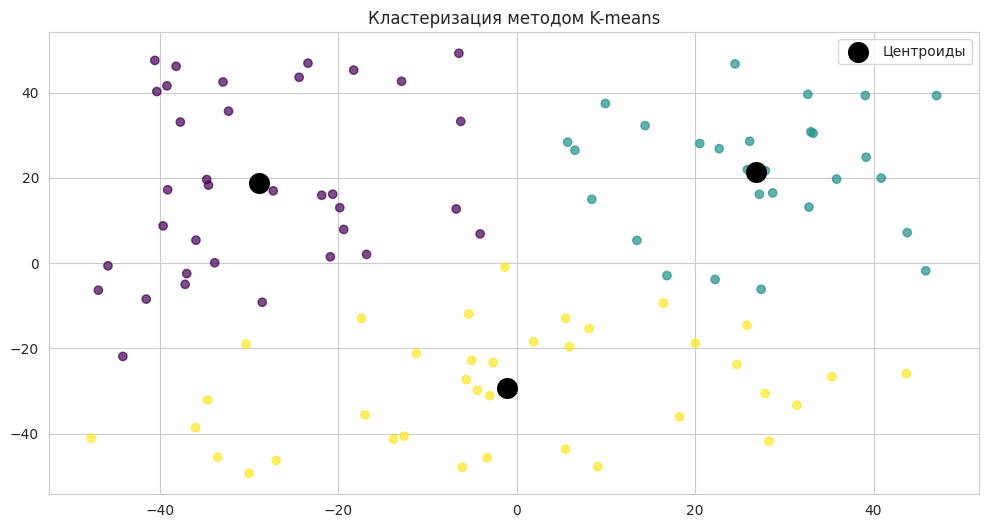

In [ ]:
# Создание синтетических координат точек
rng = np.random.default_rng(seed=42)
points = rng.uniform(low=-50, high=50, size=(100, 2))

# Выполнение кластеризации
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(points)
centroids = kmeans.cluster_centers_

# Построение графика
plt.scatter(points[:,0], points[:,1], c=labels, cmap='viridis', alpha=0.7)
plt.scatter(centroids[:,0], centroids[:,1], marker='o', color='black', s=200, label='Центроиды')
plt.legend()
plt.title('Кластеризация методом K-means')
plt.show()


----------------------------------------------------------------------

✅ Задание №4.

Цель: Изучение классификации методом логистической регрессии и интерпретация результатов.
Описание задания:

Возьмите готовый фрагмент кода с логистической регрессией и выполните шаги:

- Увеличьте размер обучающего множества и повторите эксперименты (увеличьте количество образцов в два раза).
- Исследуйте, как меняется точность модели при изменении класса разделения (class_sep), делая классы менее чётко различимыми.
- Интерпретируйте изменения в отчёте классификации и матрице путаницы при уменьшении различия между классами.

Задание:

In [ ]:
# Синтетические данные для классификации
X, Y = make_classification(n_samples=100, n_features=2, n_informative=2,
                           n_redundant=0, class_sep=1.0, random_state=42)

# Разделение на тренировочный и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Тренировка логистической регрессии
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

# Прогнозы и метрика точности
predictions = clf.predict(X_test)
report = classification_report(y_test, predictions)
confusion_mtx = confusion_matrix(y_test, predictions)

print(report)
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted labels'); plt.ylabel('True labels');
plt.title('Матрица путаницы логистической регрессии')
plt.show()

Решение:

              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       0.90      1.00      0.95         9

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20



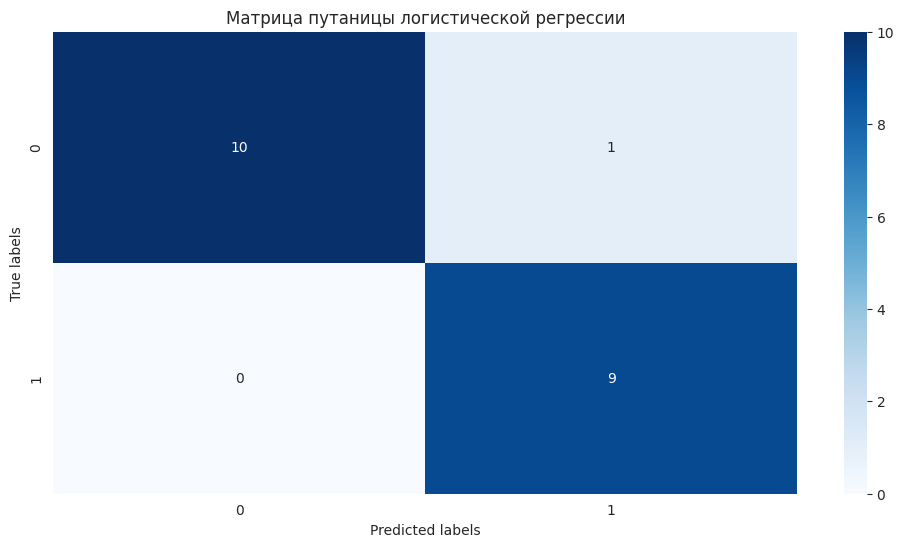

In [ ]:
# Синтетические данные для классификации
X, Y = make_classification(n_samples=100, n_features=2, n_informative=2,
                           n_redundant=0, class_sep=1.0, random_state=42)

# Разделение на тренировочный и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Тренировка логистической регрессии
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

# Прогнозы и метрика точности
predictions = clf.predict(X_test)
report = classification_report(y_test, predictions)
confusion_mtx = confusion_matrix(y_test, predictions)

print(report)
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted labels'); plt.ylabel('True labels');
plt.title('Матрица путаницы логистической регрессии')
plt.show()

-------------------------------------------------------------------------

✅ Задание №5.

Цель: Узнать принципы построения и тренировки простой полносвязанной нейронной сети.
Описание задания:

Основываясь на вашем фрагменте кода с нейронной сетью:

- Экспериментально определите лучшее количество нейронов в скрытой слое (попробуйте варианты с 4, 8, 16 нейронами).
- Добавьте ещё один скрытый слой и сравните, насколько улучшается точность предсказания.
- Постройте график зависимостей потерь и точности от эпохи для лучшего найденного варианта архитектуры.



Задание:

In [ ]:
# То же самое разбиение данных
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X, Y, test_size=0.2, random_state=42)

# Модель нейронной сети
nn_model = Sequential([
    Dense(8, input_shape=(2,), activation='relu'),  # Скрытый слой
    Dense(1, activation='sigmoid')                  # Выходной слой
])

# Компилирование и обучение модели
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = nn_model.fit(X_train_nn, y_train_nn, validation_data=(X_test_nn, y_test_nn),
                       epochs=100, batch_size=10, verbose=0)

# Проверка результата
test_loss, test_acc = nn_model.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"\nТестовая потеря: {test_loss:.4f}, Тестовая точность: {test_acc:.4f}")

# График потерь
pd.DataFrame(history.history).plot()
plt.title('Потеря и точность по эпохам')
plt.show()

Решение:

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Тестовая потеря: 0.1605, Тестовая точность: 0.9500


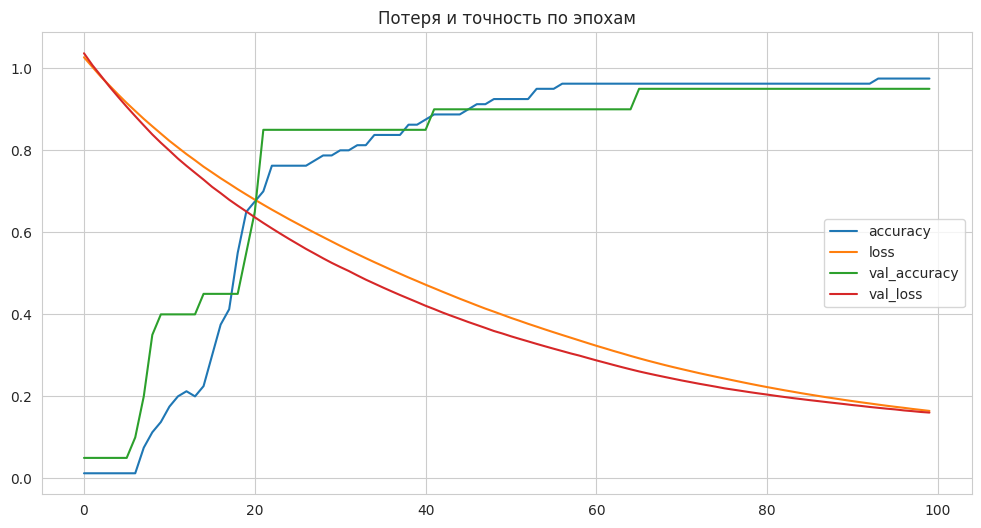

In [ ]:
# То же самое разбиение данных
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X, Y, test_size=0.2, random_state=42)

# Модель нейронной сети
nn_model = Sequential([
    Dense(8, input_shape=(2,), activation='relu'),  # Скрытый слой
    Dense(1, activation='sigmoid')                  # Выходной слой
])

# Компилирование и обучение модели
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = nn_model.fit(X_train_nn, y_train_nn, validation_data=(X_test_nn, y_test_nn),
                       epochs=100, batch_size=10, verbose=0)

# Проверка результата
test_loss, test_acc = nn_model.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"\nТестовая потеря: {test_loss:.4f}, Тестовая точность: {test_acc:.4f}")

# График потерь
pd.DataFrame(history.history).plot()
plt.title('Потеря и точность по эпохам')
plt.show()

------------------------------------------------------------------------